<a href="https://colab.research.google.com/github/Atharv-Chopade/Deep-Learning/blob/main/DL_Day_10_P2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project 2: CNN

Dataset: MNIST

Compare:

With vs Without Dropout

1 Conv Layer vs 2 Conv Layers

In [42]:
from tensorflow.keras.datasets import mnist

In [43]:
(X_train , y_train) , (X_test , y_test) = mnist.load_data()

In [44]:
X_train = X_train/255
X_test = X_test/255

In [45]:
X_train.reshape(-1,28,28,1)
X_test.reshape(-1,28,28,1)

array([[[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]]],


       [[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
 

In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D , Dense , Dropout, Flatten , MaxPooling2D

with dropout

In [71]:
model = Sequential()
model.add(Conv2D(32 ,kernel_size= (3,3) , activation = 'relu' , input_shape = (28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dropout(0.2))
model.add(Dense(128 , activation = 'relu'))
model.add(Dense(10 , activation = 'softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [72]:
model.compile(optimizer='adam' , loss = 'sparse_categorical_crossentropy' , metrics = ['accuracy'])

In [73]:
model.fit(X_train , y_train , epochs = 5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - accuracy: 0.9506 - loss: 0.1616
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.9813 - loss: 0.0597
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 23ms/step - accuracy: 0.9873 - loss: 0.0401
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.9908 - loss: 0.0286
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 22ms/step - accuracy: 0.9936 - loss: 0.0206


In [74]:
loss , accuracy = model.evaluate(X_test , y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9872 - loss: 0.0388


In [76]:
y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [77]:
y_pred.argmax(axis = 1)

array([7, 2, 1, ..., 4, 5, 6])

In [78]:
import matplotlib.pyplot as plt

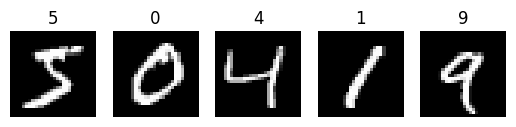

In [81]:
for i in range(5):
  plt.subplot(1,5,i+1)
  plt.imshow(X_train[i].reshape(28,28) , cmap = 'gray')
  plt.title(y_train[i])
  plt.axis(False)

Without Dropout

In [83]:
model = Sequential()
model.add(Conv2D(32 , kernel_size = (3,3) , activation = 'relu' , input_shape = (28,28,1)))
model.add(MaxPooling2D(pool_size = (2,2)))
model.add(Flatten())
model.add(Dense(128 , activation = 'relu'))
model.add(Dense(10 , activation = 'softmax'))

In [85]:
model.compile(optimizer='adam' , loss = 'sparse_categorical_crossentropy' , metrics = ['accuracy'])

In [86]:
model.fit(X_train , y_train , epochs = 5, validation_split = 0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.9492 - loss: 0.1685 - val_accuracy: 0.9769 - val_loss: 0.0736
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 34s 23ms/step - accuracy: 0.9828 - loss: 0.0564 - val_accuracy: 0.9833 - val_loss: 0.0570
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 38s 26ms/step - accuracy: 0.9883 - loss: 0.0359 - val_accuracy: 0.9819 - val_loss: 0.0582
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 33s 22ms/step - accuracy: 0.9928 - loss: 0.0229 - val_accuracy: 0.9824 - val_loss: 0.0581
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.9954 - loss: 0.0150 - val_accuracy: 0.9845 - val_loss: 0.0566


In [87]:
loss,accuracy = model.evaluate(X_test , y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9839 - loss: 0.0533


In [88]:
y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [89]:
y_pred.argmax(axis = 1)

array([7, 2, 1, ..., 4, 5, 6])

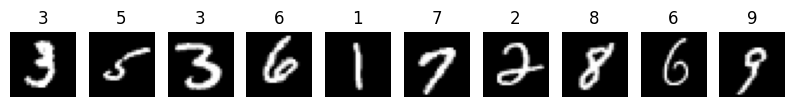

In [101]:
plt.figure(figsize = (10,10))
for i in range(10 , 20):
  plt.subplot(10,10,i+1)
  plt.imshow(X_train[i].reshape(28,28) , cmap = 'gray')
  plt.title(y_train[i])
  plt.axis(False)

1 Conv layer

In [103]:
model1conv2D = Sequential()
model1conv2D.add(Conv2D(32 , kernel_size = (3,3) , activation = 'relu' ,  input_shape = (28,28,1)))
model1conv2D.add(MaxPooling2D(pool_size = (2,2)))
model1conv2D.add(Flatten())
model1conv2D.add(Dense(128 , activation = 'relu'))
model1conv2D.add(Dense(10 ,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [106]:
model1conv2D.compile(optimizer = 'adam' , loss = 'sparse_categorical_crossentropy' , metrics = ['accuracy'])

In [107]:
layer1 = model1conv2D.fit(X_train , y_train ,epochs = 5, validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - accuracy: 0.9482 - loss: 0.1706 - val_accuracy: 0.9793 - val_loss: 0.0722
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 40s 23ms/step - accuracy: 0.9824 - loss: 0.0574 - val_accuracy: 0.9841 - val_loss: 0.0527
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 34s 23ms/step - accuracy: 0.9889 - loss: 0.0366 - val_accuracy: 0.9867 - val_loss: 0.0487
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 40s 22ms/step - accuracy: 0.9925 - loss: 0.0240 - val_accuracy: 0.9833 - val_loss: 0.0556
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - accuracy: 0.9945 - loss: 0.0173 - val_accuracy: 0.9862 - val_loss: 0.0554


In [115]:
loss1 , acc1 = model1conv2D.evaluate(X_test , y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9841 - loss: 0.0527


2 Conv2D layer

In [111]:
model2conv2D = Sequential()
model2conv2D.add(Conv2D(64 , kernel_size = (3,3) , activation = 'relu' , input_shape = (28,28,1)))
model2conv2D.add(MaxPooling2D(pool_size = (2,2)))
model2conv2D.add(Conv2D(32, kernel_size = (3,3) , activation = 'relu' , input_shape = (28,28,1)))
model2conv2D.add(MaxPooling2D(pool_size = (2,2)))
model2conv2D.add(Flatten())
model2conv2D.add(Dense(128 , activation = 'relu'))
model2conv2D.add(Dense(10 , activation = 'softmax'))
model2conv2D.compile(optimizer='adam' , loss = 'sparse_categorical_crossentropy' , metrics= ['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [114]:
layer2 = model2conv2D.fit(X_train , y_train , epochs = 5 , validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 60s 40ms/step - accuracy: 0.9809 - loss: 0.0637 - val_accuracy: 0.9836 - val_loss: 0.0575
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 39ms/step - accuracy: 0.9867 - loss: 0.0416 - val_accuracy: 0.9862 - val_loss: 0.0501
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 54s 36ms/step - accuracy: 0.9909 - loss: 0.0290 - val_accuracy: 0.9873 - val_loss: 0.0417
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 36ms/step - accuracy: 0.9927 - loss: 0.0219 - val_accuracy: 0.9883 - val_loss: 0.0447
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 54s 36ms/step - accuracy: 0.9941 - loss: 0.0171 - val_accuracy: 0.9883 - val_loss: 0.0411


In [116]:
loss2 , acc2 = model2conv2D.evaluate(X_test , y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9890 - loss: 0.0393


Text(0.5, 1.0, '1layer vs 2layer Conv2D')

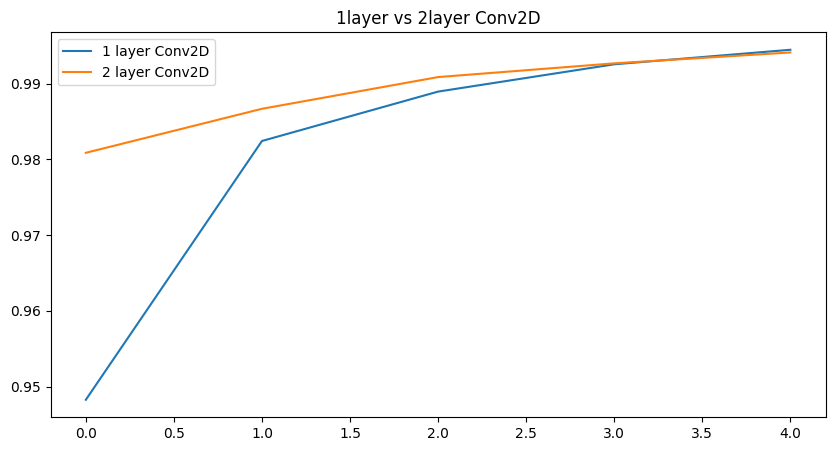

In [118]:
plt.figure(figsize = (10,5))
plt.plot(layer1.history['accuracy'] , label = '1 layer Conv2D')
plt.plot(layer2.history['accuracy'] , label = '2 layer Conv2D')
plt.legend()
plt.title('1layer vs 2layer Conv2D')

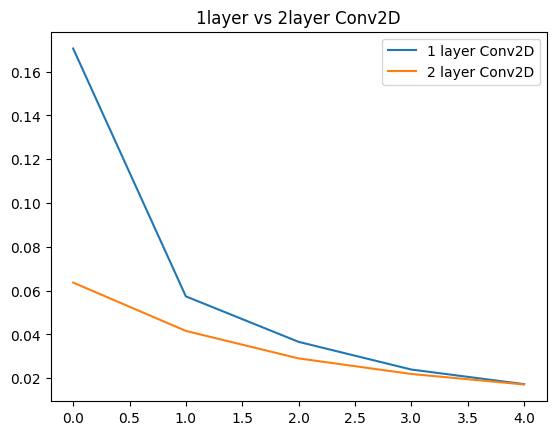

In [119]:
plt.plot(layer1.history['loss'] , label = '1 layer Conv2D')
plt.plot(layer2.history['loss'] , label = '2 layer Conv2D')
plt.legend()
plt.title('1layer vs 2layer Conv2D')
plt.show()

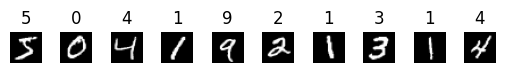

In [120]:
for i in range(10):
  plt.subplot(10,10,i+1)
  plt.imshow(X_train[i].reshape(28,28) , cmap = 'gray')
  plt.title(y_train[i])
  plt.axis(False)